Text(0.5, 0, 'Time (s)')

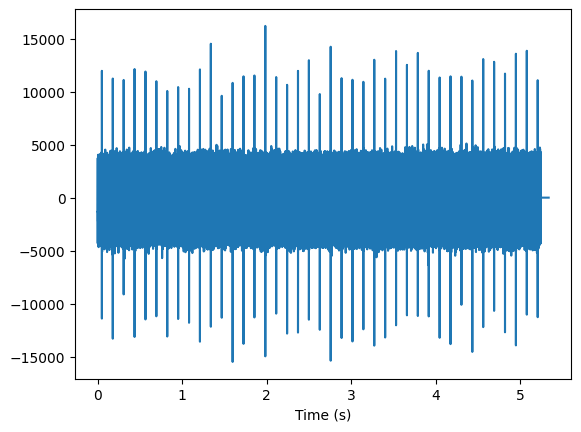

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

data_directory = Path(r'C:\Users\Splinter-User\Documents\Code\GaGe_Digitzer_Python\data_backup')
data_path = data_directory / '2025-09-15T11-13-50_ch1.npy'
data = np.load(data_path)

sample_rate_Hz = 100e6
sample_spacing_s = 1 / sample_rate_Hz

x_axis = np.arange(0, len(data)*sample_spacing_s, sample_spacing_s)


plt.plot(x_axis, data)
plt.xlabel('Time (s)')

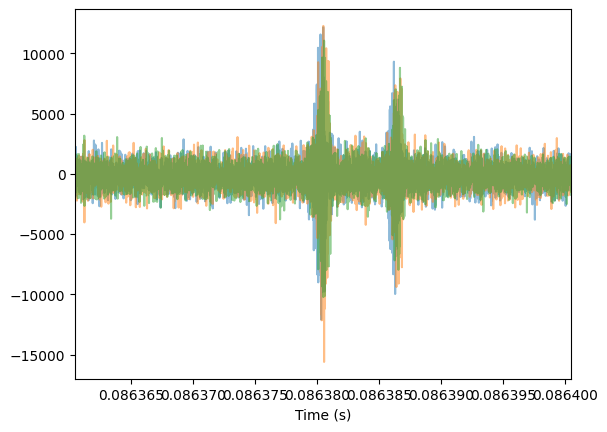

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.signal import find_peaks

# Load data
data_directory = Path(r'C:\Users\Splinter-User\Documents\Code\GaGe_Digitzer_Python\data_backup')
data_path = data_directory / '2025-09-15T11-11-52_ch1.npy'
data = np.load(data_path)

# parameters
sample_rate_Hz = 100e6
sample_spacing_s = 1 / sample_rate_Hz

# Find interferograms
ifg_locs = find_peaks(data, height=10000, distance = 10000)[0]
ifg_loc = ifg_locs[0]
ifg_peak_time_s = ifg_loc*sample_spacing_s

# Chop signal by ifg
ifg_spacings = np.diff(ifg_locs)
ifg_spacing = int(np.mean(ifg_spacings))

ifgs = []

i=0
while i < len(data) - 2*ifg_spacing:
    ifg = data[i:i+ifg_spacing]
    ifgs.append(ifg)
    i += ifg_spacing

# Calculate x axis
x_axis = np.arange(0, ifg_spacing*sample_spacing_s, sample_spacing_s)

# Plot ifgs
window_s = 4e-5
for ifg in ifgs:
    plt.plot(x_axis, ifg, alpha = .5)
    plt.xlim(ifg_peak_time_s - window_s/2, ifg_peak_time_s + window_s/2)
    plt.xlabel('Time (s)')

Time to load data:  0.3 s
Time to find ifgs:  6.2 s
Time to xcorr overlap:  3.2 s


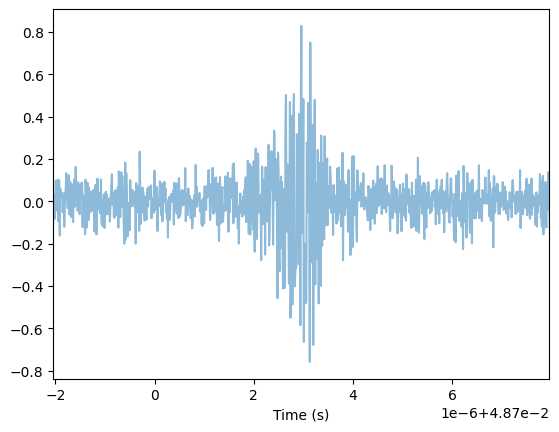

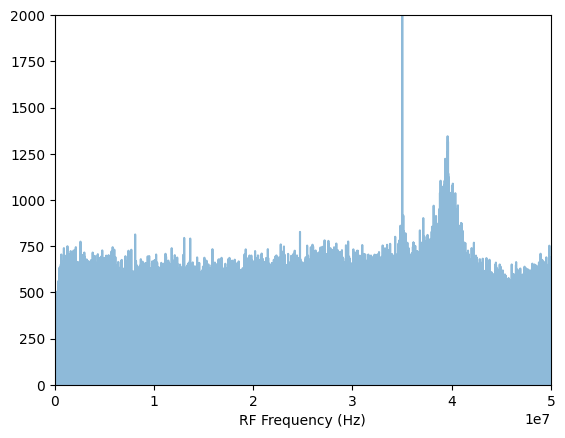

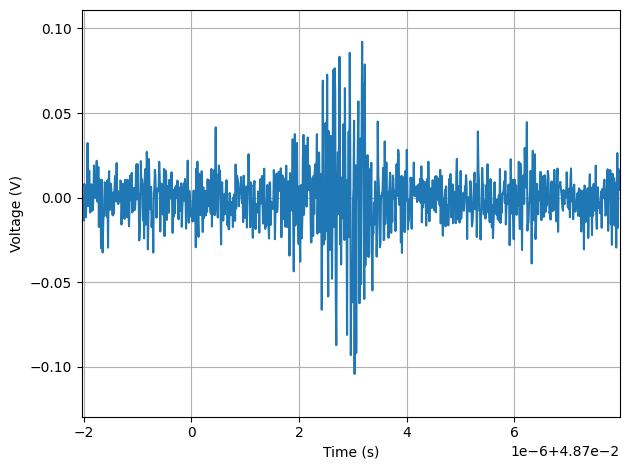

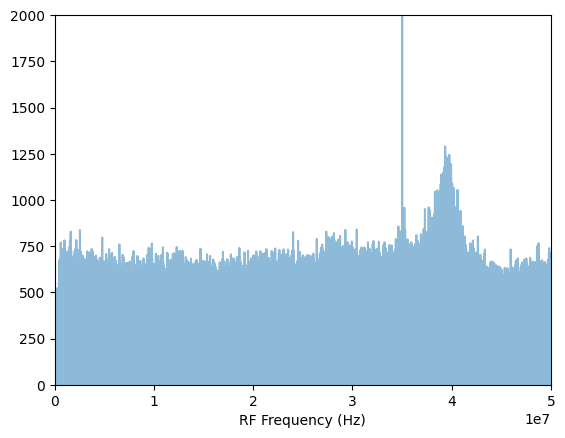

Time to plot:  9.3 s


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.signal import find_peaks, hilbert, correlate
from scipy.fft import fft, fftfreq, fftshift
from time import time

# Load data
time_start = time()
data_directory = Path(r'C:\Users\Splinter-User\Documents\Code\GaGe_Digitzer_Python\data_backup')
data_path = data_directory / '2025-09-15T11-13-50_ch1.npy'
# data_path = data_directory / '2025-09-15T11-13-50_ch1.npy'
data = np.load(data_path)

time_load = time()
print(f'Time to load data: {time_load - time_start: .1f} s')
# parameters
sample_rate_Hz = 100e6
sample_spacing_s = 1 / sample_rate_Hz
dfr_Hz = 7.7
relative_Vmax = 0.4
xcorr_window_size = 1e-4

# Massage data
data = data - np.mean(data)

# Find interferograms based on peak of hilbert magnitude
# ifg_hilbert = np.abs(hilbert(data))
ifg_locs = find_peaks(data, height= relative_Vmax * np.max(data), distance = sample_rate_Hz / (4*dfr_Hz))[0]
ifg_loc = ifg_locs[0]
ifg_peak_time_s = ifg_loc*sample_spacing_s

# Chop signal by ifg
ifg_spacings = np.diff(ifg_locs)
ifg_spacing = int(np.mean(ifg_spacings))

ifgs = []
i=0
# Drop the last ifg. Not the right length
while i < len(data) - 2*ifg_spacing:
    ifg = data[i:i+ifg_spacing]
    ifgs.append(ifg)
    i += ifg_spacing

time_find = time()
print(f'Time to find ifgs: {time_find - time_load: .1f} s')
# Overlap ifgs according to cross correlation
ifg_ref = ifgs[0]
ifg_ref_windowed = ifg_ref[ifg_loc - int(xcorr_window_size*sample_rate_Hz/dfr_Hz): ifg_loc + int(xcorr_window_size*sample_rate_Hz/dfr_Hz)]
ifg_ref_envelope = np.abs(hilbert(ifg_ref_windowed))
ifgs[0]= ifg_ref/ np.max(ifg_ref_envelope) 

for i, ifg in enumerate(ifgs):
    ifg_windowed = ifg[ifg_loc - int(xcorr_window_size*sample_rate_Hz/dfr_Hz): ifg_loc + int(xcorr_window_size*sample_rate_Hz/dfr_Hz)]
    ifg_envelope = np.abs(hilbert(ifg_windowed))
    ifg = ifg / np.max(ifg_envelope)
    ifg_xcorr = correlate(ifg_ref_envelope, ifg_envelope)
    ifg_xcorr_amax = np.argmax(ifg_xcorr)
    ifg = np.roll(ifg, ifg_xcorr_amax)
    ifgs[i] = ifg

time_xcorr = time()
print(f'Time to xcorr overlap: {time_xcorr - time_find: .1f} s')

# Calculate x axis
x_axis = np.arange(0, ifg_spacing*sample_spacing_s, sample_spacing_s)

# Plot ifgs
window_s = 1e-5
center_s = np.argmax(ifgs[0]) * sample_spacing_s
for ifg in ifgs[0:1]:
    plt.plot(x_axis, ifg, alpha = .5)
    plt.xlim(center_s - window_s/2, center_s + window_s/2)
    plt.xlabel('Time (s)')

plt.show()

# Plot spectra
f_axis = fftfreq(ifg_spacing,d=sample_spacing_s)

for ifg in ifgs[0:1]:
    plt.plot(f_axis, np.abs(fft(ifg)), alpha = .5)
    plt.xlim(0, 50e6)
    plt.ylim(0, 2000)
    plt.xlabel('RF Frequency (Hz)')
plt.show()

# Calculate average
ifg_avg = np.zeros_like(ifgs[0])
for ifg in ifgs:
    ifg_avg += ifg
ifg_avg = ifg_avg / len(ifgs)
# Plot options

# Plot average
plt.plot(x_axis, ifg_avg, label='42 IFG Avg')
plt.grid()
plt.xlim(center_s - window_s/2, center_s + window_s/2)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.tight_layout()
plt.savefig(data_directory/'average_ifg.png', dpi=300)
plt.show()

plt.plot(f_axis, np.abs(fft(ifg)), alpha = .5)
plt.xlim(0, 50e6)
plt.ylim(0, 2000)
plt.xlabel('RF Frequency (Hz)')
plt.show()
time_plot = time()
print(f'Time to plot: {time_plot - time_xcorr: .1f} s')